In [8]:
import shap
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Load Model + Data

In [9]:
xgb = joblib.load('../outputs/xgb_model.pkl')
X_train, X_test, y_train, y_test = joblib.load('../outputs/processed_data.pkl')

In [10]:
# Use a sample for speed (SHAP on full set is slow)
X_sample = X_test.sample(5000, random_state=42)

SHAP Explainer

In [11]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_sample)

print("SHAP values computed.")

SHAP values computed.


Global — Feature Importance (Beeswarm)

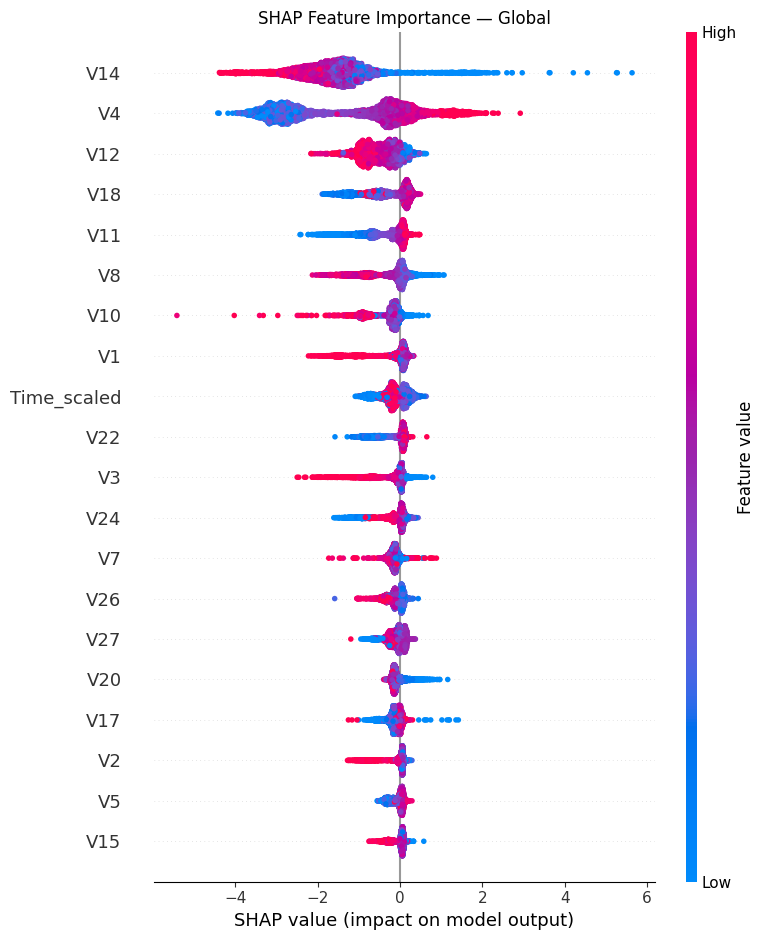

Saved: shap_summary.png


In [12]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_sample, show=False)
plt.title('SHAP Feature Importance — Global')
plt.tight_layout()
plt.savefig('../outputs/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_summary.png")

Global — Bar Chart

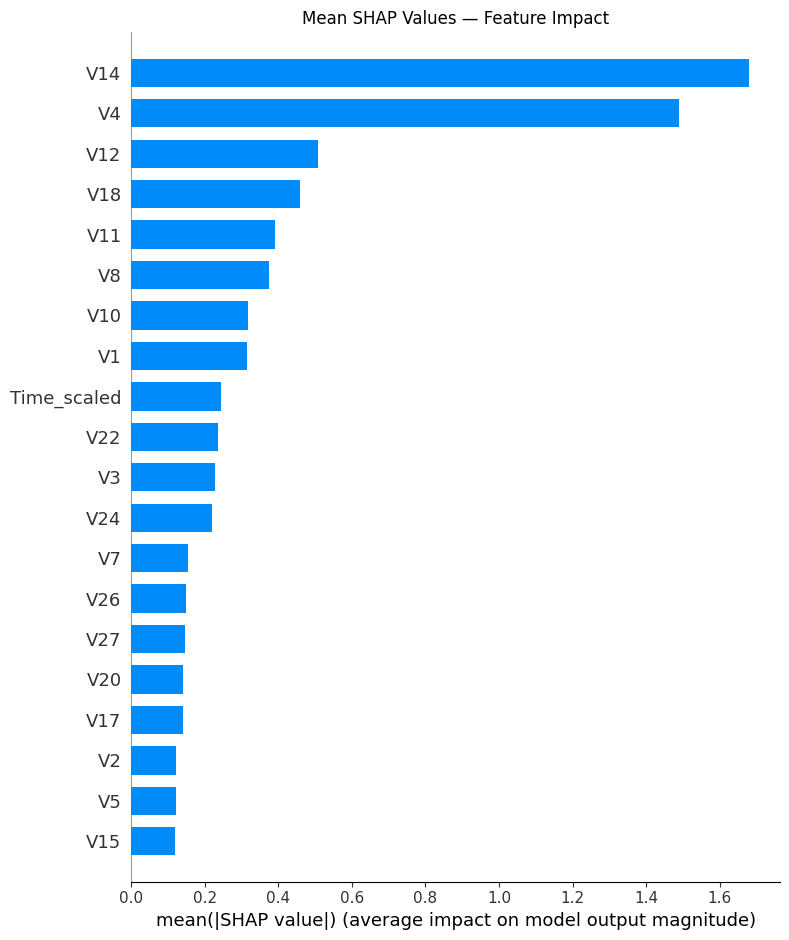

Saved: shap_bar.png


In [13]:
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_sample, plot_type='bar', show=False)
plt.title('Mean SHAP Values — Feature Impact')
plt.tight_layout()
plt.savefig('../outputs/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_bar.png")

Local — Single Prediction Explanation


Explaining fraud transaction at index: 153835


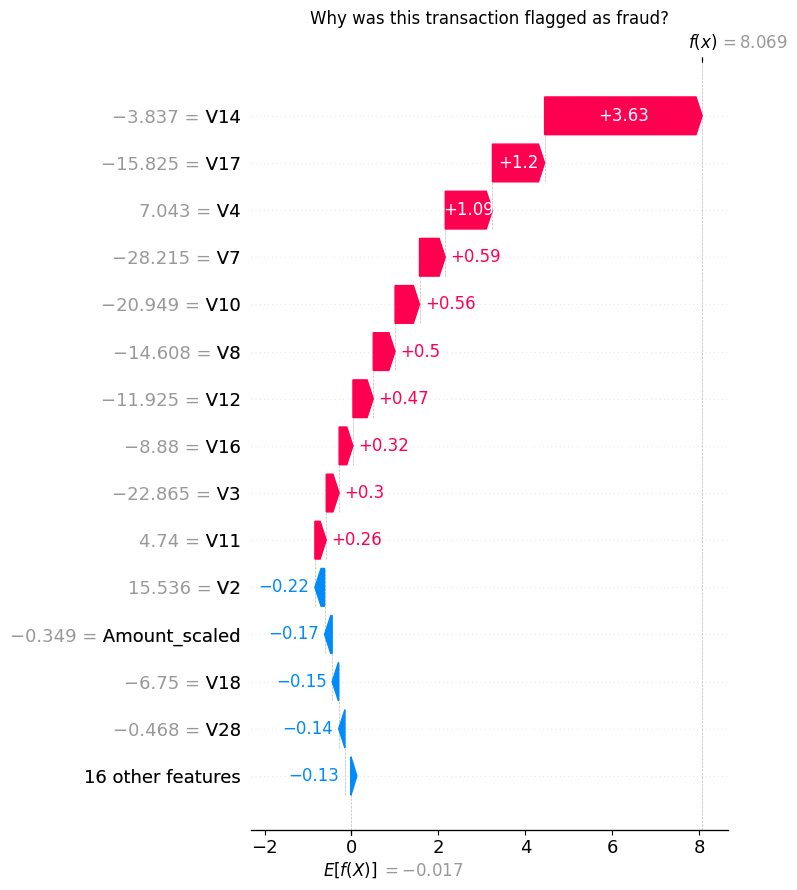

Saved: shap_waterfall_fraud.png

✅ Explainability complete. All plots saved to /outputs/


In [14]:
# Find a fraud case in sample
y_sample = y_test.loc[X_sample.index]
fraud_indices = y_sample[y_sample == 1].index

if len(fraud_indices) > 0:
    fraud_idx = fraud_indices[0]
    pos = X_sample.index.get_loc(fraud_idx)
    
    print(f"\nExplaining fraud transaction at index: {fraud_idx}")
    
    # Waterfall plot for single prediction
    shap_explanation = shap.Explanation(
        values=shap_values[pos],
        base_values=explainer.expected_value,
        data=X_sample.iloc[pos],
        feature_names=X_sample.columns.tolist()
    )
    
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(shap_explanation, max_display=15, show=False)
    plt.title(f'Why was this transaction flagged as fraud?')
    plt.tight_layout()
    plt.savefig('../outputs/shap_waterfall_fraud.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: shap_waterfall_fraud.png")
else:
    print("No fraud cases in sample — increase sample size.")

print("\n✅ Explainability complete. All plots saved to /outputs/")
